# Análise da relação entre indicadores econômicos brasileiros e ações da B3

## 1. Introdução

Este notebook descreve historicamente uma amostra de ações negociadas na B3 e indicadores macroeconômicos brasileiros. A análise exploratória utiliza as bases processadas disponíveis, enquanto a análise conjunta da Etapa 4 utiliza exclusivamente março de 2012 a dezembro de 2022. Não são utilizados algoritmos de predição.

As observações devem ser interpretadas como descrições históricas da amostra, sem inferência de causalidade ou recomendação de investimento.

## 2. Dados utilizados

A análise utiliza exclusivamente os dados processados:

- `data/processed/stocks_monthly.csv`;
- `data/processed/economic_indicators_monthly.csv`.

A base de ações contém métricas mensais calculadas com `Adj Close` para retorno e volatilidade. `Close` é mantido como referência não ajustada. A amostra possui 215 tickers selecionados por critérios de cobertura e qualidade. A origem externa dos dois CSV de entrada não está comprovada: não se atribui seu fornecimento à B3, Yahoo, Kaggle, BCB, IBGE ou FGV. As referências oficiais discutidas no [README](../README.md) são apenas conceituais, não evidências de procedência ou de identificação das séries observadas.

## 3. Preparação dos dados

A limpeza e a agregação foram executadas por `prepare_data.py`. Os dados brutos não são alterados. No arquivo auditado, IPCA, IGP-M, INPC e desemprego têm um único valor não nulo por mês; o pipeline não os replica diariamente. `selic_media_mensal` é a média dos níveis registrados diariamente, não juros acumulados; `selic_final_mes` é o último nível registrado no mês. `selic_variacao_mensal_pontos` guarda a diferença mensal na unidade original da série Selic, entre níveis de fim de mês, sem confirmação de pontos percentuais.

O retorno mensal é `Adj Close` do último registro válido do mês dividido pelo correspondente do mês anterior, menos 1, exigindo meses consecutivos. A operação confirma a conversão para percentual: `retorno (%) = 100 × retorno`. A volatilidade é o desvio-padrão amostral, não anualizado, dos retornos entre registros válidos, agrupados pelo mês do registro atual; possíveis lacunas impedem tratar todos esses intervalos como sessões consecutivas. Nas tabelas, retornos e volatilidade permanecem em escala decimal; sua multiplicação por 100 expressa a escala percentual dos retornos.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, HTML

ROOT = Path.cwd().parent if (Path.cwd() / 'data').exists() is False else Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path.cwd().parent
TABLES = ROOT / 'outputs' / 'tables'
FIGURES = ROOT / 'outputs' / 'figures'
stocks = pd.read_csv(ROOT / 'data' / 'processed' / 'stocks_monthly.csv')
economic = pd.read_csv(ROOT / 'data' / 'processed' / 'economic_indicators_monthly.csv')
stocks['month'] = pd.PeriodIndex(stocks['month'], freq='M')
economic['month'] = pd.PeriodIndex(economic['month'], freq='M')
print(f'Ações: {len(stocks):,} observações mensais; {stocks.Symbol.nunique()} tickers')
print(f'Indicadores: {len(economic):,} meses')
display(stocks.head())
display(economic.head())

Ações: 29,415 observações mensais; 215 tickers
Indicadores: 154 meses


,Symbol,month,month_end_close,month_end_adj_close,volume_mean,volume_total,valid_sessions,volatility_daily_return,previous_month_end_adj_close,previous_month,monthly_return
0,ABTT34,2012-05,30.309999,25.153019,922.727273,20300.0,22,0.000000,NaN,NaN,NaN
1,ABTT34,2012-06,30.309999,25.153019,0.000000,0.0,20,0.000000,25.153019,2012-05,0.000000
2,ABTT34,2012-07,30.309999,25.368477,0.000000,0.0,21,0.001869,25.153019,2012-06,0.008566
3,ABTT34,2012-08,30.309999,25.368477,0.000000,0.0,23,0.000000,25.368477,2012-07,0.000000
4,ABTT34,2012-09,35.459999,29.678850,110.526316,2100.0,19,0.038980,25.368477,2012-08,0.169911


,month,selic_media_mensal,selic_final_mes,ipca,igpm,inpc,desemprego_pnadc,selic_variacao_mensal_pontos
0,2012-03,9.919355,9.75,0.21,0.43,0.18,8.0,-0.75
1,2012-04,9.450000,9.00,0.64,0.85,0.64,7.8,-0.75
2,2012-05,8.983871,8.50,0.36,1.02,0.55,7.7,-0.50
3,2012-06,8.500000,8.50,0.08,0.66,0.26,7.6,0.00
4,2012-07,8.177419,8.00,0.43,1.34,0.43,7.5,-0.50


## 4. Análise exploratória

### 4.1 Ações da B3

As tabelas abaixo resumem retorno mensal, volatilidade não anualizada, volumes e quantidade de registros válidos. Os extremos observados na amostra saneada são apresentados separadamente como maiores retornos positivos e maiores quedas, com ticker e mês. Não são atribuídas explicações econômicas aos eventos sem evidência externa. A unidade de Volume e a metodologia de ajuste de Adj Close não estão comprovadas pela documentação dos arquivos.

In [2]:
stock_stats = pd.read_csv(TABLES / 'stock_descriptive_statistics.csv')
stock_extremes = pd.read_csv(TABLES / 'stock_return_extremes.csv')
display(stock_stats)
print('Dez maiores retornos positivos entre os extremos salvos (escala decimal):')
display(stock_extremes.loc[stock_extremes['monthly_return'].gt(0)].nlargest(10, 'monthly_return'))
print('Dez menores retornos negativos entre os extremos salvos (escala decimal):')
display(stock_extremes.loc[stock_extremes['monthly_return'].lt(0)].nsmallest(10, 'monthly_return'))

,metric,count,missing,mean,median,std,min,q25,q75,max
0,monthly_return,29193,222,1.229005e-02,0.000000,2.019925e-01,-0.9375,-0.052632,5.676324e-02,1.196296e+01
1,volatility_daily_return,29404,11,2.547452e-02,0.020279,4.834014e-02,0.0000,0.013006,3.025135e-02,4.518701e+00
2,volume_mean,29415,0,2.245583e+06,23822.727273,7.894666e+06,0.0000,361.904762,1.278142e+06,2.008178e+08
3,volume_total,29415,0,4.502936e+07,480386.000000,1.602430e+08,0.0000,7240.000000,2.532895e+07,4.618809e+09
4,valid_sessions,29415,0,2.028815e+01,21.000000,2.506723e+00,1.0000,19.000000,2.200000e+01,2.300000e+01


Dez maiores retornos positivos entre os extremos salvos (escala decimal):


,extreme_type,Symbol,month,monthly_return,volatility_daily_return,valid_sessions
19,highest_return,DMMO3,2015-04,11.962963,1.506333,20
18,highest_return,MGLU3,2024-05,8.110294,1.810749,21
17,highest_return,BPAR3,2018-10,7.668199,1.634866,22
16,highest_return,OIBR4,2024-06,6.825581,1.995586,18
15,highest_return,CPLE5,2021-06,6.766027,0.675112,21
14,highest_return,CEPE3,2020-12,6.032967,0.386188,20
13,highest_return,MMXM3,2020-10,5.421349,0.646337,21
12,highest_return,TELB3,2019-08,4.769231,0.395248,22
11,highest_return,SAPR3,2013-06,4.125002,0.922378,20
10,highest_return,EUCA3,2019-12,3.733333,0.435964,19


Dez menores retornos negativos entre os extremos salvos (escala decimal):


,extreme_type,Symbol,month,monthly_return,volatility_daily_return,valid_sessions
20,lowest_return,PDGR3,2024-09,-0.937500,0.240372,15
21,lowest_return,F11,2024-12,-0.904552,0.207966,19
22,lowest_return,CAMB3,2016-06,-0.900000,0.191881,22
23,lowest_return,PCAR3,2020-05,-0.872952,0.195446,20
24,lowest_return,CPLE5,2020-05,-0.846456,0.239523,20
25,lowest_return,LUPA3,2014-11,-0.844828,0.215245,19
26,lowest_return,RNEW3,2017-03,-0.828244,0.113474,23
27,lowest_return,DMMO3,2016-01,-0.796667,0.176949,19
28,lowest_return,ATMP3,2018-05,-0.730673,0.059572,21
29,lowest_return,DMMO3,2019-12,-0.718269,0.149240,19


### 4.2 Indicadores econômicos

As estatísticas econômicas são exibidas como **valores na unidade original do CSV (não confirmada)**. Nenhuma unidade macroeconômica foi comprovada. A Selic provavelmente representa uma taxa em % a.a., possivelmente a meta; IPCA, IGP-M e INPC provavelmente representam variações percentuais mensais; PNADC provavelmente representa uma taxa percentual referente a trimestre móvel. Essas hipóteses não identificam as séries nem autorizam rotular os valores observados com essas unidades. A diferença mensal da Selic também permanece na unidade original, sem confirmação de p.p.

In [3]:
economic_stats = pd.read_csv(TABLES / 'economic_descriptive_statistics.csv')
display(economic_stats)

,metric,count,missing,mean,median,std,min,q25,q75,max,period_start,period_end
0,selic_media_mensal,154,0,9.407396,10.169355,3.681859,2.00,6.5000,12.7625,14.25,2012-03,2024-12
1,selic_final_mes,154,0,9.413961,10.125000,3.688369,2.00,6.5000,12.7500,14.25,2012-03,2024-12
2,selic_variacao_mensal_pontos,154,0,0.011364,0.000000,0.440348,-1.00,0.0000,0.0000,1.50,2012-03,2024-12
3,ipca,154,0,0.472727,0.435000,0.374737,-0.68,0.2400,0.6850,1.62,2012-03,2024-12
4,igpm,154,0,0.608312,0.530000,0.959982,-1.93,0.1500,0.9475,4.34,2012-03,2024-12
5,inpc,154,0,0.472532,0.450000,0.403280,-0.60,0.1825,0.7050,1.71,2012-03,2024-12
6,desemprego_pnadc,154,0,10.045455,9.450000,2.664756,6.10,7.5250,12.3000,14.90,2012-03,2024-12


### 4.3 Comportamento agregado da amostra

A série agregada representa o comportamento típico dos ativos selecionados, e não um índice de mercado. A mediana é priorizada porque reduz a influência de retornos extremos. A quantidade de ativos válidos é mostrada para evidenciar mudanças na composição da amostra.

In [4]:
market_summary = pd.read_csv(TABLES / 'monthly_market_summary.csv')
extremes = pd.read_csv(TABLES / 'extreme_months.csv')
display(market_summary.head())
display(extremes)

,month,median_monthly_return,mean_monthly_return,median_volatility,mean_volatility,assets_with_month_data,valid_return_assets,positive_return_assets,negative_return_assets,positive_return_proportion,negative_return_proportion
0,2012-03,0.000000,0.021242,0.018441,0.019974,186,184,87,60,0.472826,0.326087
1,2012-04,0.000000,-0.008848,0.016315,0.017826,189,186,76,88,0.408602,0.473118
2,2012-05,-0.047619,-0.044627,0.021505,0.024927,193,189,40,124,0.211640,0.656085
3,2012-06,0.000000,-0.000294,0.019655,0.020006,194,193,90,56,0.466321,0.290155
4,2012-07,0.000000,0.012326,0.019401,0.018782,196,194,81,69,0.417526,0.355670


,metric,direction,rank,month,value,valid_return_assets
0,median_monthly_return,lowest,1,2020-03,-0.263623,210
1,median_monthly_return,lowest,2,2022-06,-0.082126,213
2,median_monthly_return,lowest,3,2022-11,-0.067404,210
3,median_monthly_return,lowest,4,2020-02,-0.066172,210
4,median_monthly_return,lowest,5,2013-06,-0.062572,200
5,median_monthly_return,lowest,6,2018-05,-0.057687,210
6,median_monthly_return,lowest,7,2015-08,-0.056250,209
7,median_monthly_return,lowest,8,2022-12,-0.055620,207
8,median_monthly_return,lowest,9,2018-06,-0.053392,210
9,median_monthly_return,lowest,10,2021-10,-0.053130,210


## 5. Visualizações

Os gráficos foram gerados a partir das tabelas processadas. A distribuição dos retornos possui uma versão completa e outra limitada visualmente aos percentis 1 e 99; esse recorte visual não altera a base já saneada nem implica ausência de exclusões na preparação. Os valores macroeconômicos são apresentados na unidade original do CSV, não confirmada.

- **Selic:** mostra a trajetória da média mensal e do valor ao fim do mês.
- **Inflação:** compara os valores registrados sob os rótulos IPCA, IGP-M e INPC, sem unidade comprovada.
- **Desemprego:** mostra os valores registrados por mês sob o rótulo PNADC, sem comprovação da unidade ou da janela de referência.
- **Retorno típico:** acompanha a mediana mensal dos retornos e apresenta a média apenas como referência.
- **Volatilidade:** acompanha a mediana e a média da dispersão não anualizada dos retornos entre registros válidos, agrupados por mês.
- **Distribuição:** mostra a dispersão dos retornos completos e uma versão visual sem os extremos das caudas.
- **Proporções:** compara a parcela mensal de ativos com retorno positivo e negativo.
- **Disponibilidade:** acompanha a quantidade de ativos disponíveis e com retorno válido por mês.

Selic: média dos níveis diários e último valor do mês; unidade original não comprovada.


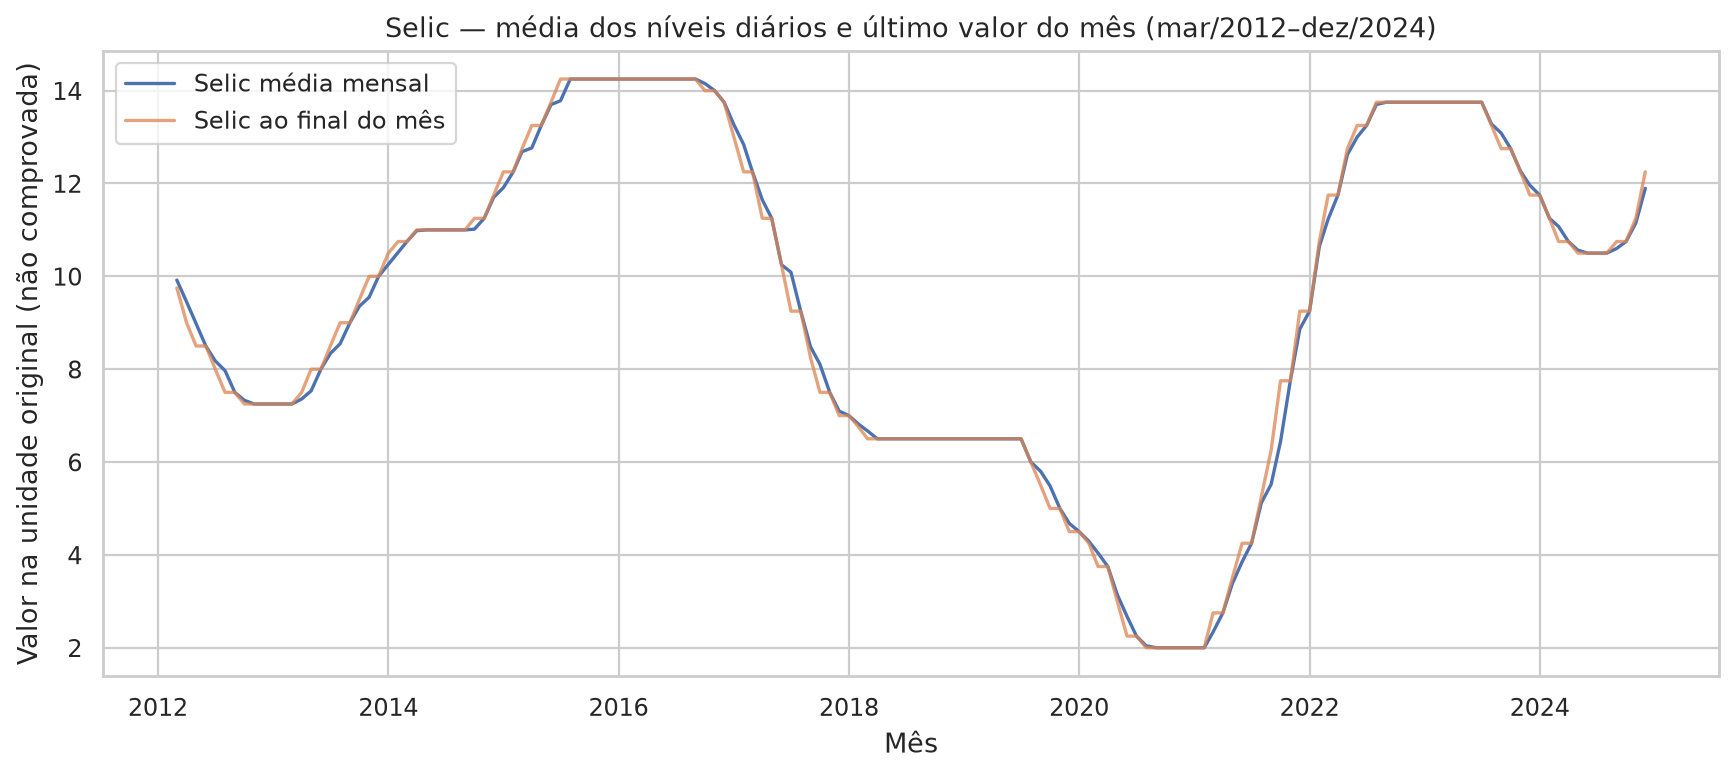

IPCA, IGP-M e INPC: valores registrados por mês; unidades não comprovadas.


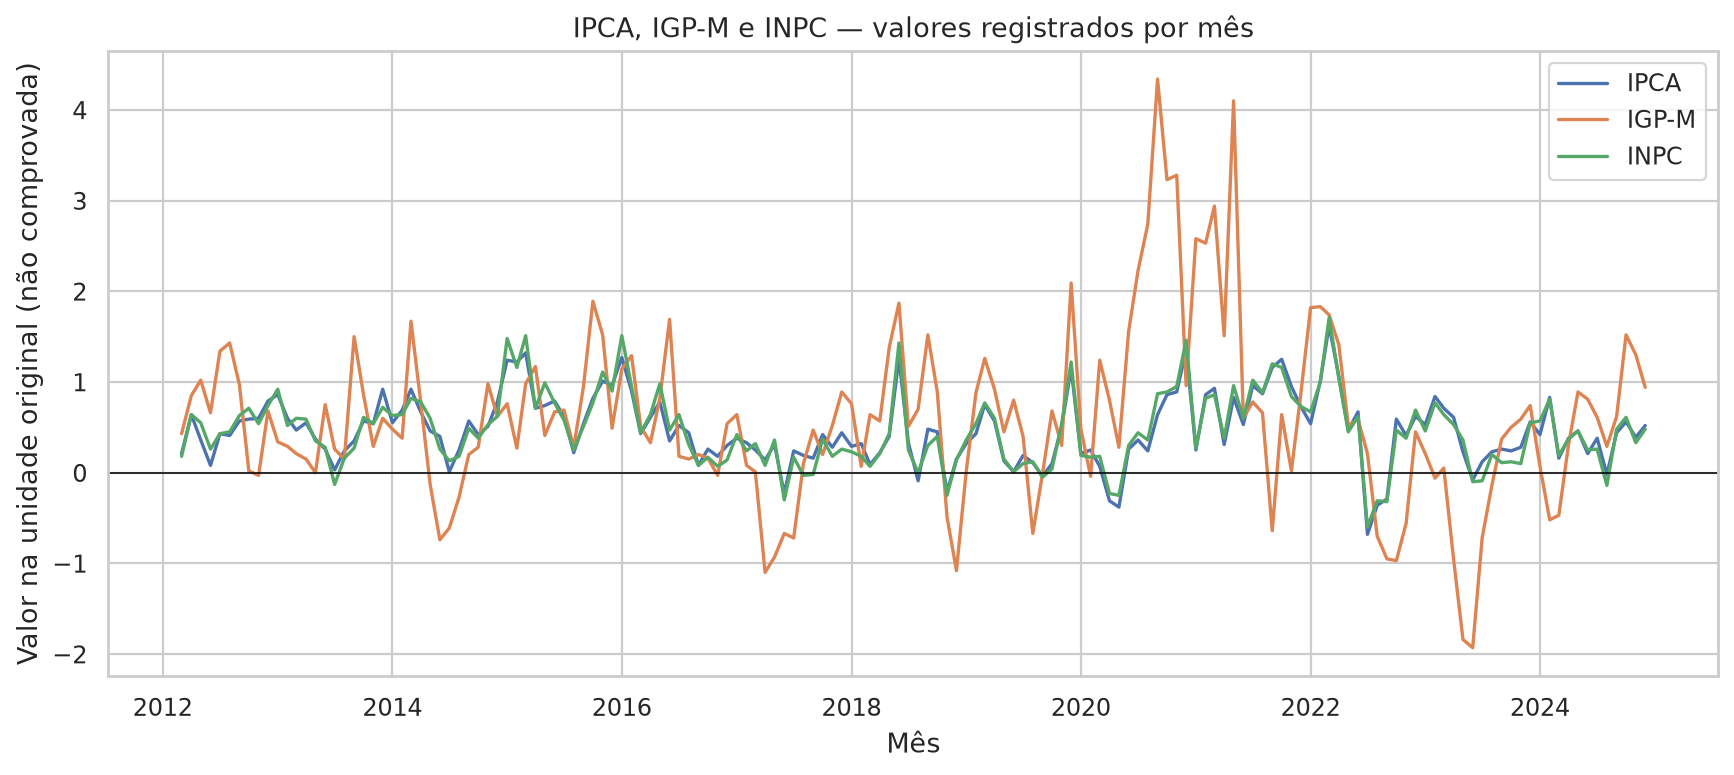

PNADC: valores identificados por mês; unidade e janela de referência não comprovadas.


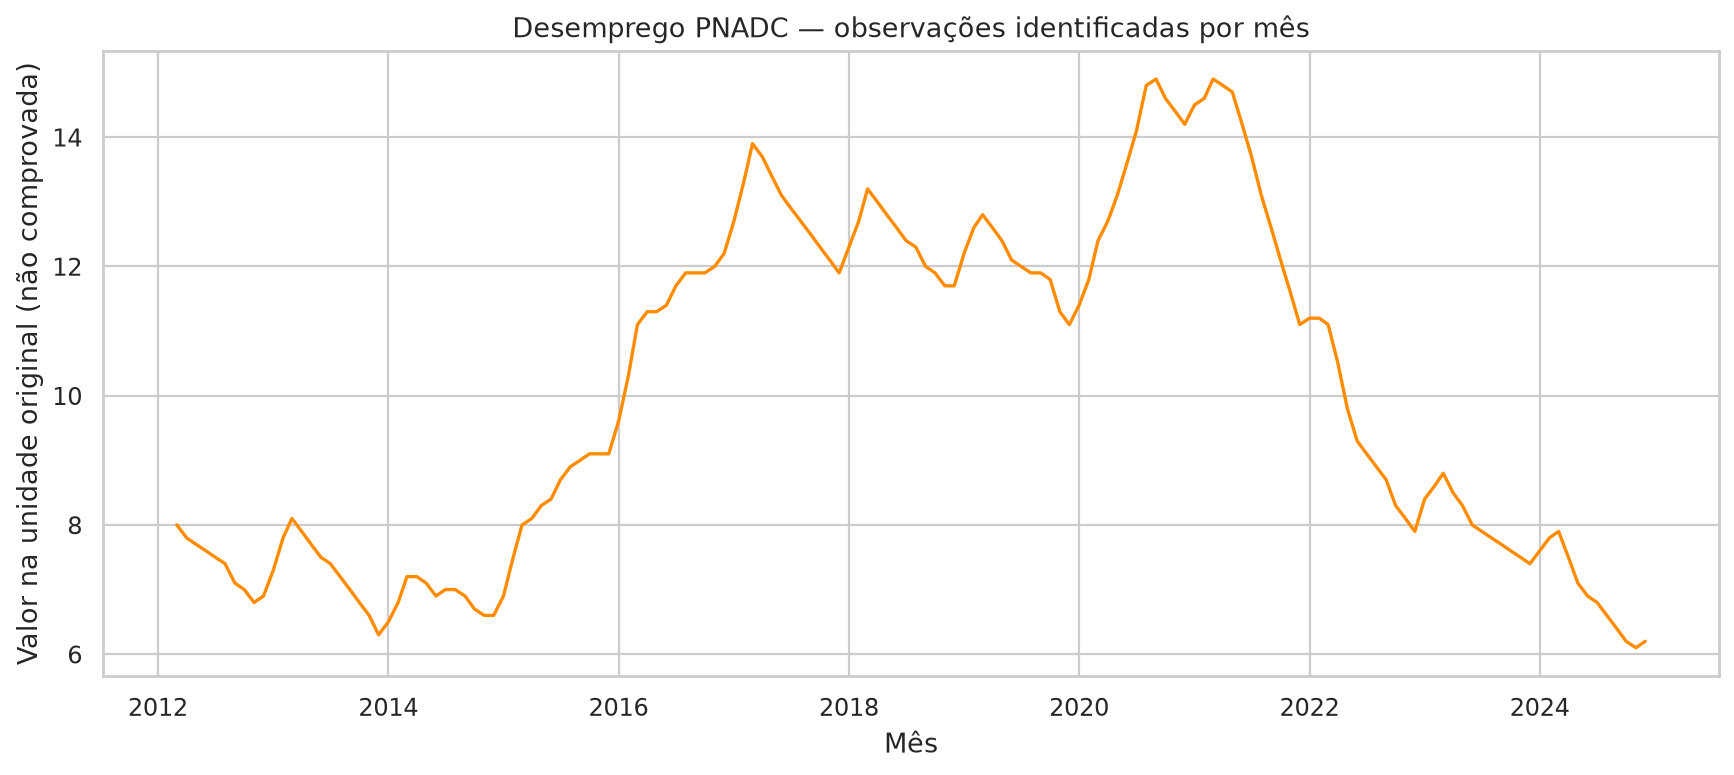

A mediana e a média dos retornos mensais da amostra.


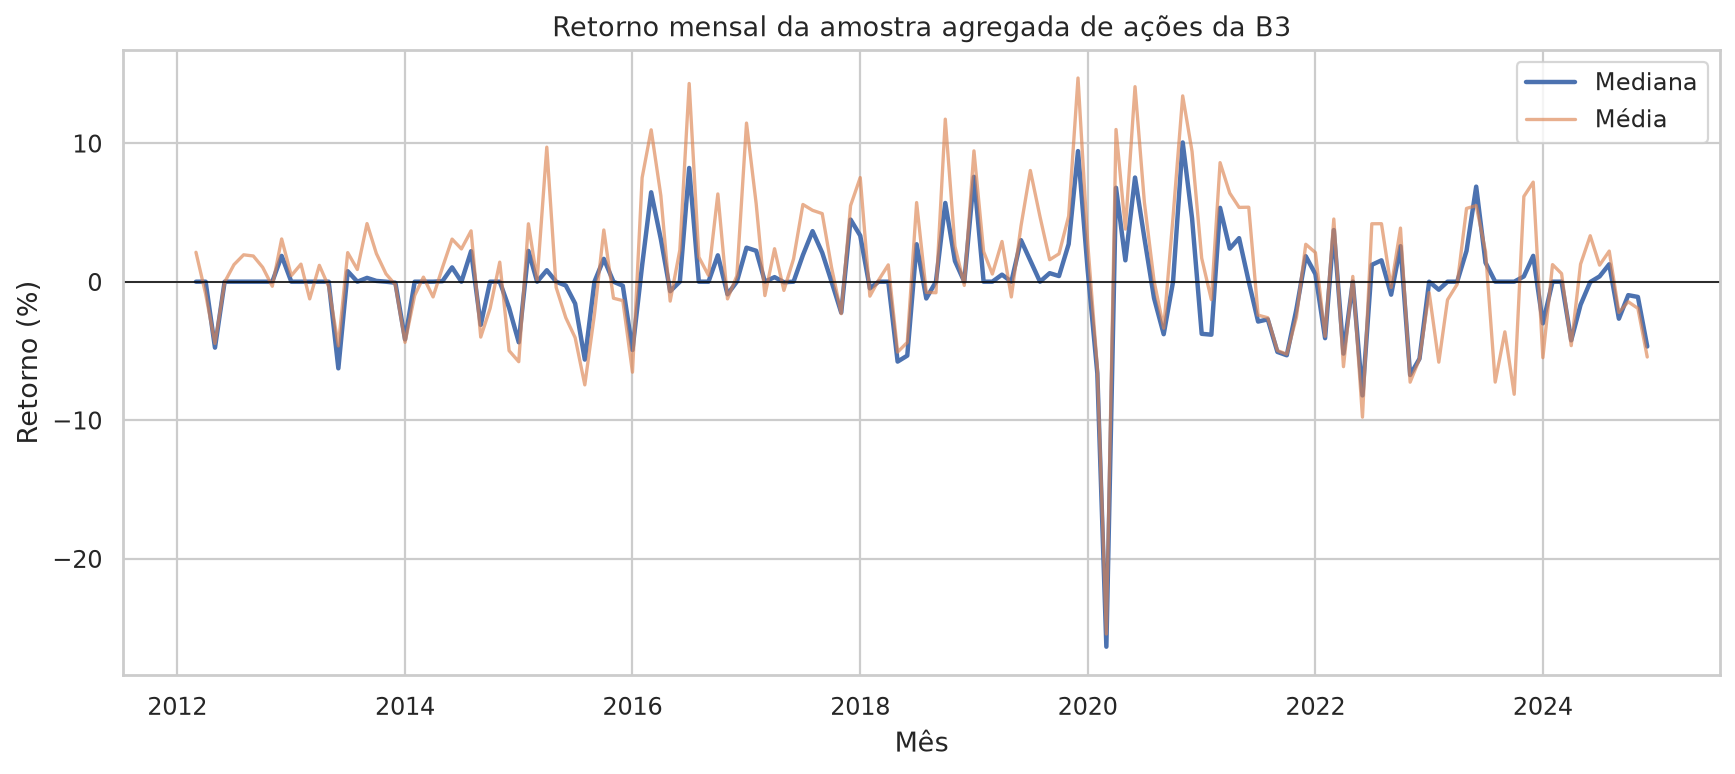

Mediana e média da volatilidade não anualizada dos retornos entre registros válidos.


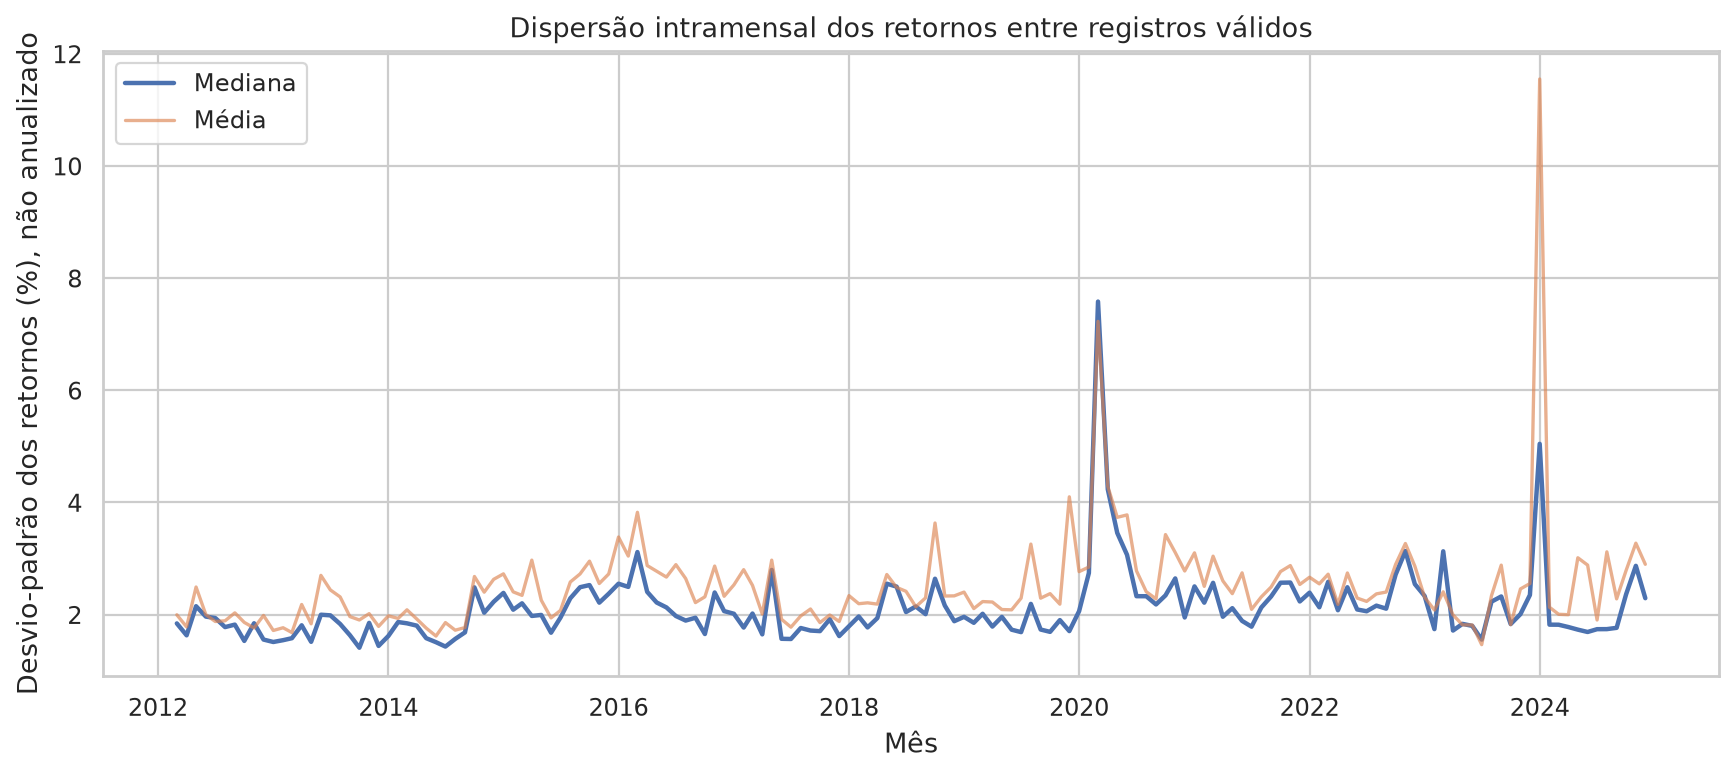

A distribuição visual dos retornos entre os percentis 1 e 99.


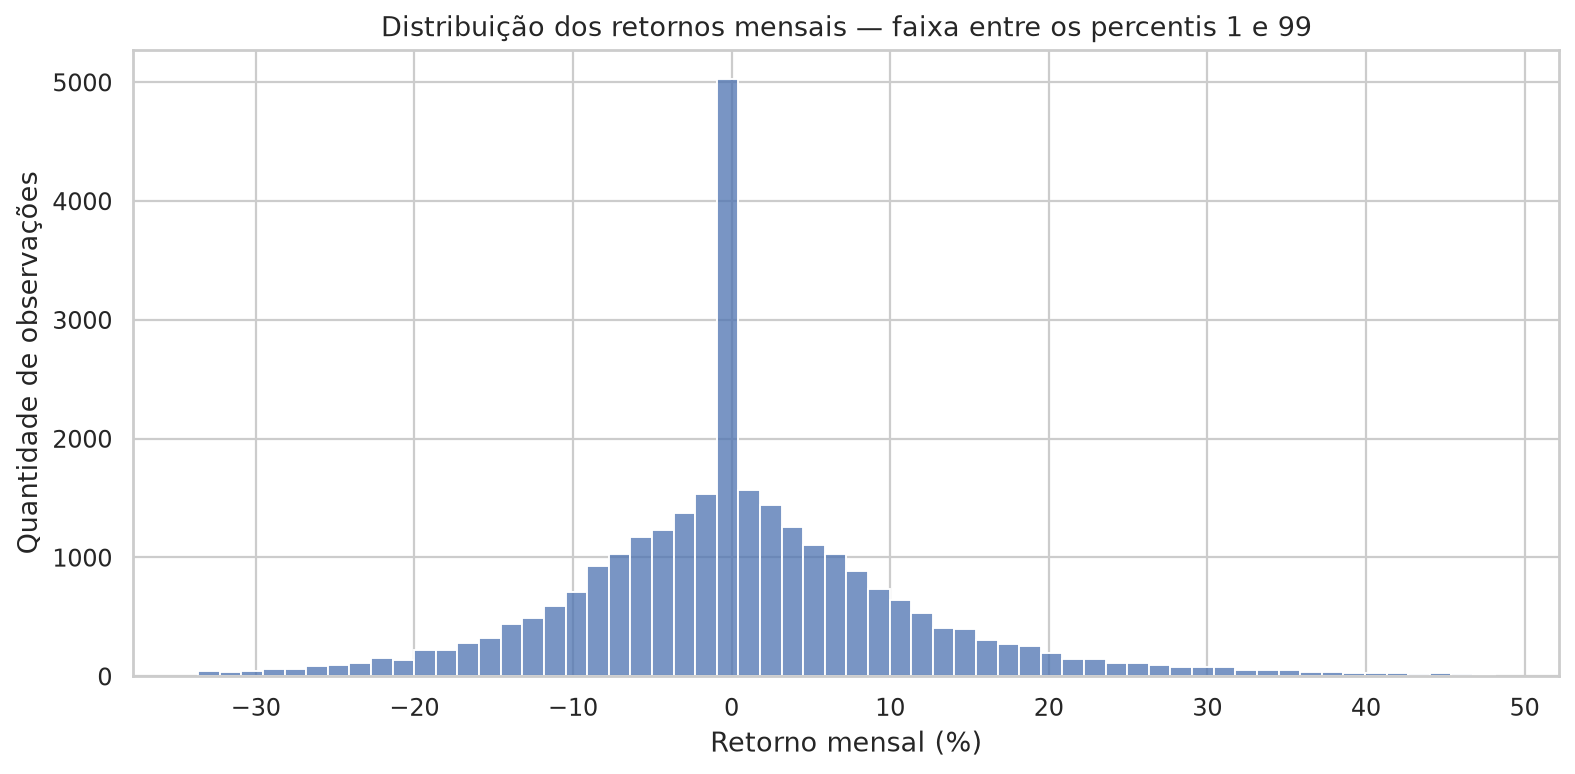

Distribuição completa dos retornos da base saneada: as caudas permanecem visíveis.


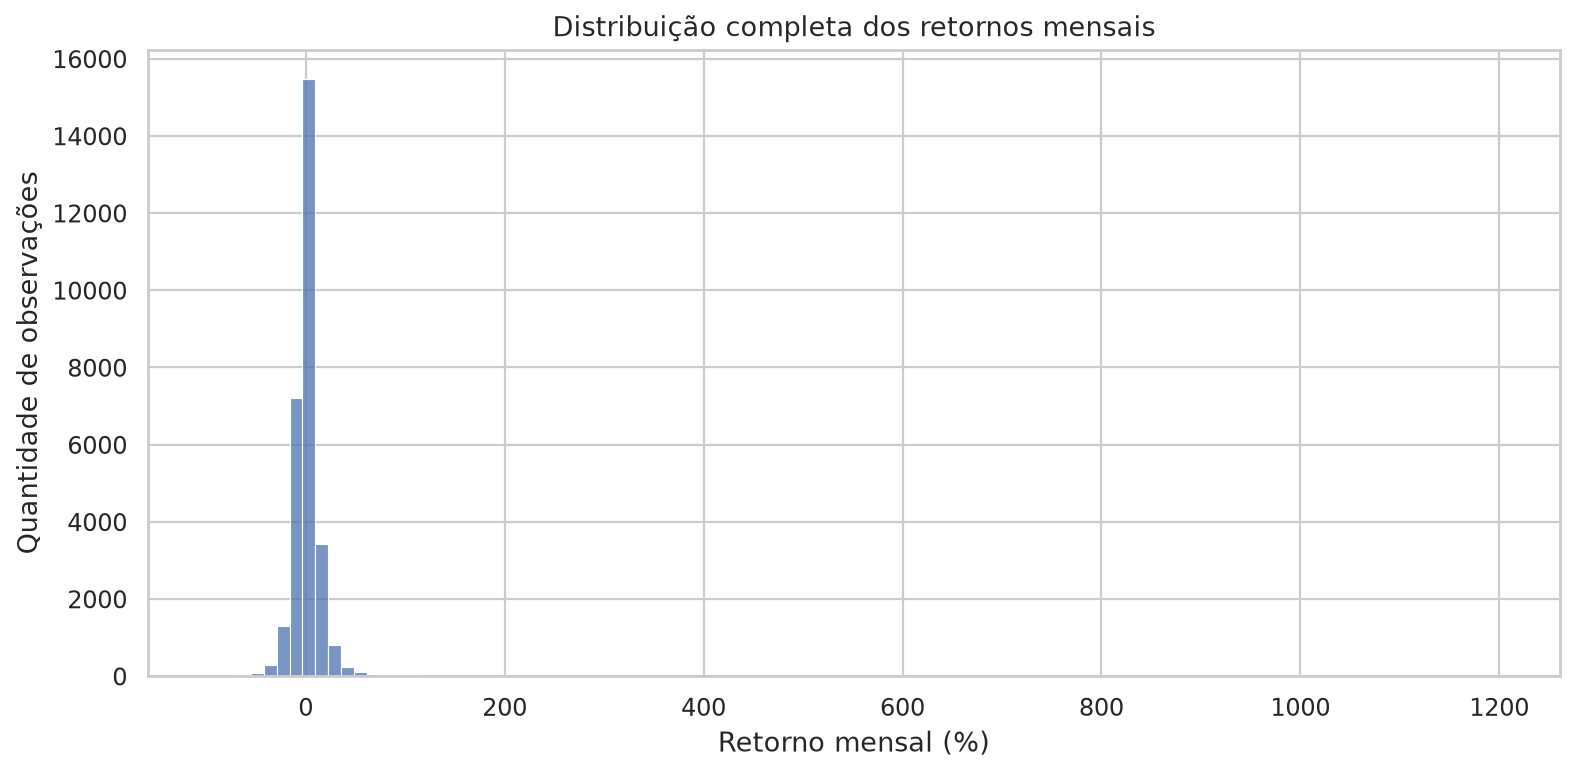

A proporção mensal de ativos com retorno positivo ou negativo.


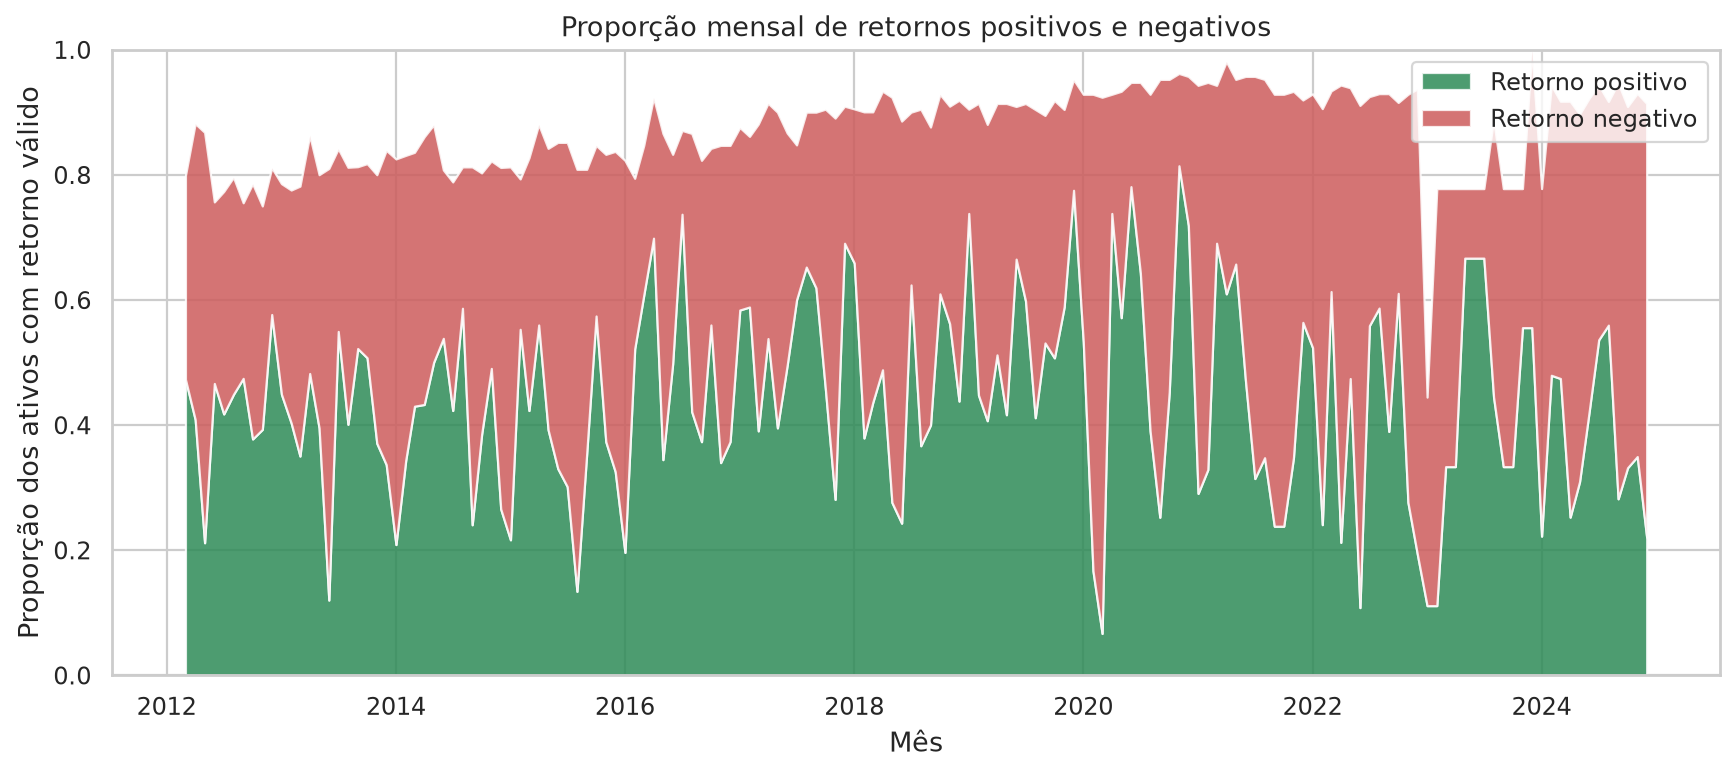

A quantidade de ativos disponíveis e com retorno válido por mês.


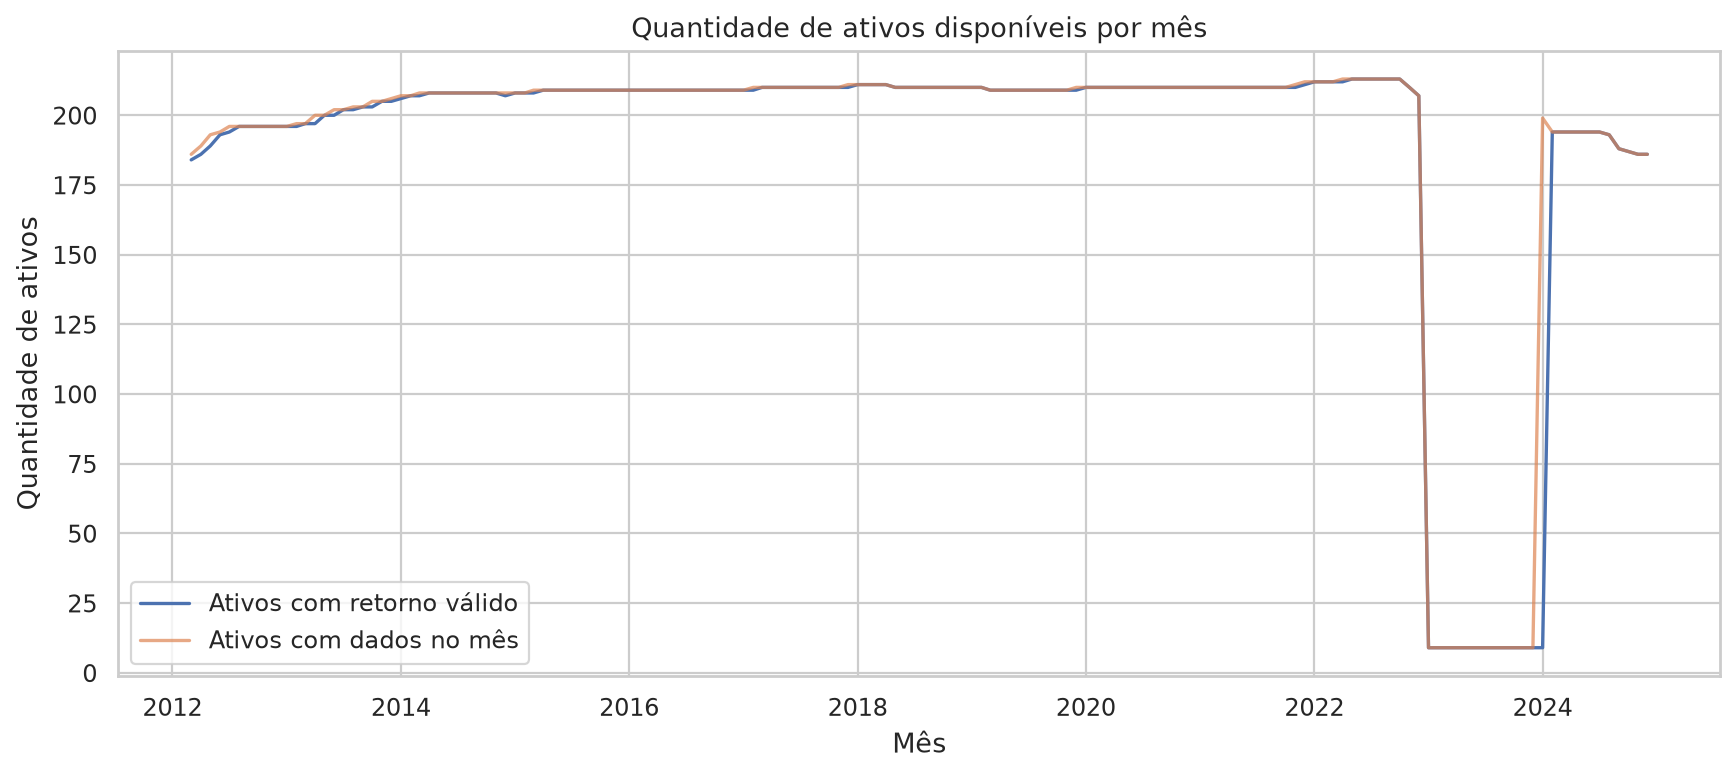

In [5]:
for name, explanation in [
    ('selic_historica.png', 'Selic: média dos níveis diários e último valor do mês; unidade original não comprovada.'),
    ('inflacao_historica.png', 'IPCA, IGP-M e INPC: valores registrados por mês; unidades não comprovadas.'),
    ('desemprego_historico.png', 'PNADC: valores identificados por mês; unidade e janela de referência não comprovadas.'),
    ('retorno_mediano_b3.png', 'A mediana e a média dos retornos mensais da amostra.'),
    ('volatilidade_mediana_b3.png', 'Mediana e média da volatilidade não anualizada dos retornos entre registros válidos.'),
    ('distribuicao_retornos.png', 'A distribuição visual dos retornos entre os percentis 1 e 99.'),
    ('distribuicao_retornos_completa.png', 'Distribuição completa dos retornos da base saneada: as caudas permanecem visíveis.'),
    ('proporcao_retornos_positivos_negativos.png', 'A proporção mensal de ativos com retorno positivo ou negativo.'),
    ('ativos_validos_por_mes.png', 'A quantidade de ativos disponíveis e com retorno válido por mês.'),
]:
    print(explanation)
    display(Image(filename=str(FIGURES / name)))

## 6. Síntese da análise exploratória

A EDA abrange os dados processados até dezembro de 2024. Os retornos apresentam caudas extremas e diferença entre média e mediana; as tabelas identificam os registros sem lhes atribuir explicações externas. Março de 2020 reúne o menor retorno mediano e a maior volatilidade mediana nas tabelas salvas. A cobertura cai para nove ativos por mês em 2023, comprometendo comparações do agregado com os anos anteriores. Presença de um ativo não garante retorno ou volatilidade válidos. A análise correlacional abaixo usa uma janela mais restrita; movimentos simultâneos não estabelecem causalidade.

## 7. Etapa 4 — análise correlacional

A análise conjunta utiliza março de 2012 a dezembro de 2022, totalizando 130 meses consecutivos. O corte decorre da quebra severa de cobertura em 2023, já presente em `data/raw/bovespa_stocks.csv`: a amostra selecionada cai para nove ativos por mês. A janela também exclui 2024 da análise conjunta; a EDA continua até dezembro de 2024. Esses registros permanecem na base processada. O corte é uma decisão operacional motivada pela cobertura observada, sem alegação de pré-especificação temporal.

A unidade de observação da análise agregada é o mês. Para cada mês, as ações são resumidas por retorno médio e mediano, volatilidade média e mediana, proporções de retornos positivos e negativos, ativos presentes e retornos válidos. Os indicadores macroeconômicos são então associados por mês. O mesmo indicador não é repetido para cada ticker-mês como se fossem observações independentes.

Pearson mede associação linear; Spearman mede associação monotônica pelos postos dos valores. A tabela compara os mesmos pares lado a lado, com coeficiente, p-value e `n_observations` (número de pares mensais válidos). Divergências podem refletir não linearidade monotônica, outliers, empates e outras propriedades da distribuição. Permutar conjuntamente os pares mensais não altera nenhum dos coeficientes; a ordenação dos meses não explica suas diferenças.

Os p-values são convencionais/nominais e não ajustados. Possível autocorrelação significa que 130 pares não são necessariamente 130 observações independentes; Spearman não resolve esse problema. O desenho contempla 84 resultados agregados (7 indicadores × 6 métricas × 2 métodos) e 6.020 individuais (215 tickers × 7 × 2 métricas × 2 métodos), sem supor testes independentes. Não há ajuste para múltiplos testes ou inferência temporal. Não se usa `p < 0,05` como conclusão confirmatória: a leitura enfatiza direção, magnitude e consistência entre métodos.

In [6]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
TABLES = ROOT / 'outputs' / 'tables'
report = json.loads((TABLES / 'correlation_report.json').read_text(encoding='utf-8'))
pearson = pd.read_csv(TABLES / 'correlation_pearson.csv')
spearman = pd.read_csv(TABLES / 'correlation_spearman.csv')
ticker_summary = pd.read_csv(TABLES / 'correlation_ticker_summary.csv')

print(f"Período: {report['period']['start']} a {report['period']['end']}")
print(f"Meses: {report['months']} | Tickers: {report['tickers']}")
print(f"Cobertura mensal: {report['monthly_asset_coverage']}")
print(f"Tickers elegíveis para a leitura principal por ticker: {report['ticker_eligible_count']} de {report['ticker_total_count']}")

def show_complete_table(frame):
    # Todas as linhas e colunas, com rolagem em vez de truncamento.
    display(HTML('<div style="max-height:520px; overflow:auto">'
                 + frame.to_html(index=False, max_rows=None, max_cols=None,
                                 float_format=lambda value: f'{value:.6g}') + '</div>'))

keys = ['macro_indicator', 'stock_metric']
values = ['coefficient', 'p_value', 'n_observations']
aggregate_comparison = pearson[keys + values].merge(
    spearman[keys + values], on=keys, how='outer', validate='one_to_one',
    suffixes=('_pearson', '_spearman')).sort_values(keys)
print('Todas as 42 relações: coeficientes, p-values nominais não ajustados e pares mensais válidos.')
show_complete_table(aggregate_comparison)

monthly_aggregate = pd.read_csv(TABLES / 'correlation_monthly_aggregate.csv')
coverage_columns = ['assets_with_month_data', 'valid_return_assets', 'valid_volatility_assets']
print('Cobertura: ativos presentes versus retornos válidos versus volatilidades válidas.')
display(monthly_aggregate[coverage_columns].agg(['min', 'median', 'max']))
print('Cobertura completa dos 130 meses (tabela com rolagem):')
show_complete_table(monthly_aggregate[['month'] + coverage_columns])

Período: 2012-03 a 2022-12


Meses: 130 | Tickers: 215
Cobertura mensal: {'minimum': 186, 'median': 209.0, 'maximum': 213}
Tickers elegíveis para a leitura principal por ticker: 212 de 215


Todas as 42 relações: coeficientes, p-values nominais não ajustados e pares mensais válidos.


macro_indicator,stock_metric,coefficient_pearson,p_value_pearson,n_observations_pearson,coefficient_spearman,p_value_spearman,n_observations_spearman
desemprego_pnadc,mean_monthly_return,0.24841,0.00437513,130,0.248262,0.0043994,130
desemprego_pnadc,mean_volatility,0.326933,0.000146769,130,0.369432,1.52166e-05,130
desemprego_pnadc,median_monthly_return,0.136646,0.121085,130,0.147954,0.0929768,130
desemprego_pnadc,median_volatility,0.235708,0.00694068,130,0.292351,0.000737706,130
desemprego_pnadc,negative_return_proportion,0.00790637,0.928862,130,0.0200603,0.820784,130
desemprego_pnadc,positive_return_proportion,0.262512,0.00255041,130,0.226597,0.00952907,130
igpm,mean_monthly_return,0.0944644,0.285047,130,0.0487426,0.581832,130
igpm,mean_volatility,0.220864,0.0115638,130,0.2531,0.00366811,130
igpm,median_monthly_return,0.0300223,0.734552,130,-0.00582238,0.947581,130
igpm,median_volatility,0.169052,0.0545136,130,0.278807,0.00131754,130


Cobertura: ativos presentes versus retornos válidos versus volatilidades válidas.


,assets_with_month_data,valid_return_assets,valid_volatility_assets
min,186.0,184.0,186.0
median,209.0,209.0,209.0
max,213.0,213.0,213.0


Cobertura completa dos 130 meses (tabela com rolagem):


month,assets_with_month_data,valid_return_assets,valid_volatility_assets
2012-03,186,184,186
2012-04,189,186,188
2012-05,193,189,193
2012-06,194,193,194
2012-07,196,194,196
2012-08,196,196,196
2012-09,196,196,196
2012-10,196,196,196
2012-11,196,196,196
2012-12,196,196,196


### Síntese dos resultados

As correlações agregadas utilizam 130 pares mensais válidos. A relação entre o indicador rotulado desemprego PNADC e volatilidade média apresenta Pearson = 0,327 e Spearman = 0,369, com direção positiva consistente nos dois métodos. Usando a volatilidade mediana, os coeficientes são menores: Pearson = 0,236 e Spearman = 0,292; o sinal permanece, mas a magnitude depende da medida agregada. Entre os coeficientes negativos, INPC e proporção de retornos positivos apresentam Spearman = −0,214; Selic no final do mês e proporção de retornos positivos apresentam Pearson = −0,189. A tabela completa permite comparar cada relação nos dois métodos sem confundir extremos de pares distintos. As magnitudes descrevem a amostra, sem evidenciar causalidade ou previsão.

Os heatmaps apresentam todas as relações, usando sinal e intensidade para comparar métodos. Os quatro scatterplots correspondem aos maiores valores absolutos de Pearson na tabela agregada: trata-se de seleção exploratória pelos próprios resultados, não evidência de previsão ou validação externa. A forma da nuvem e possíveis extremos ajudam a contextualizar os coeficientes, sem atribuir mecanismos causais.

Pearson: associação linear, todas as relações agregadas.


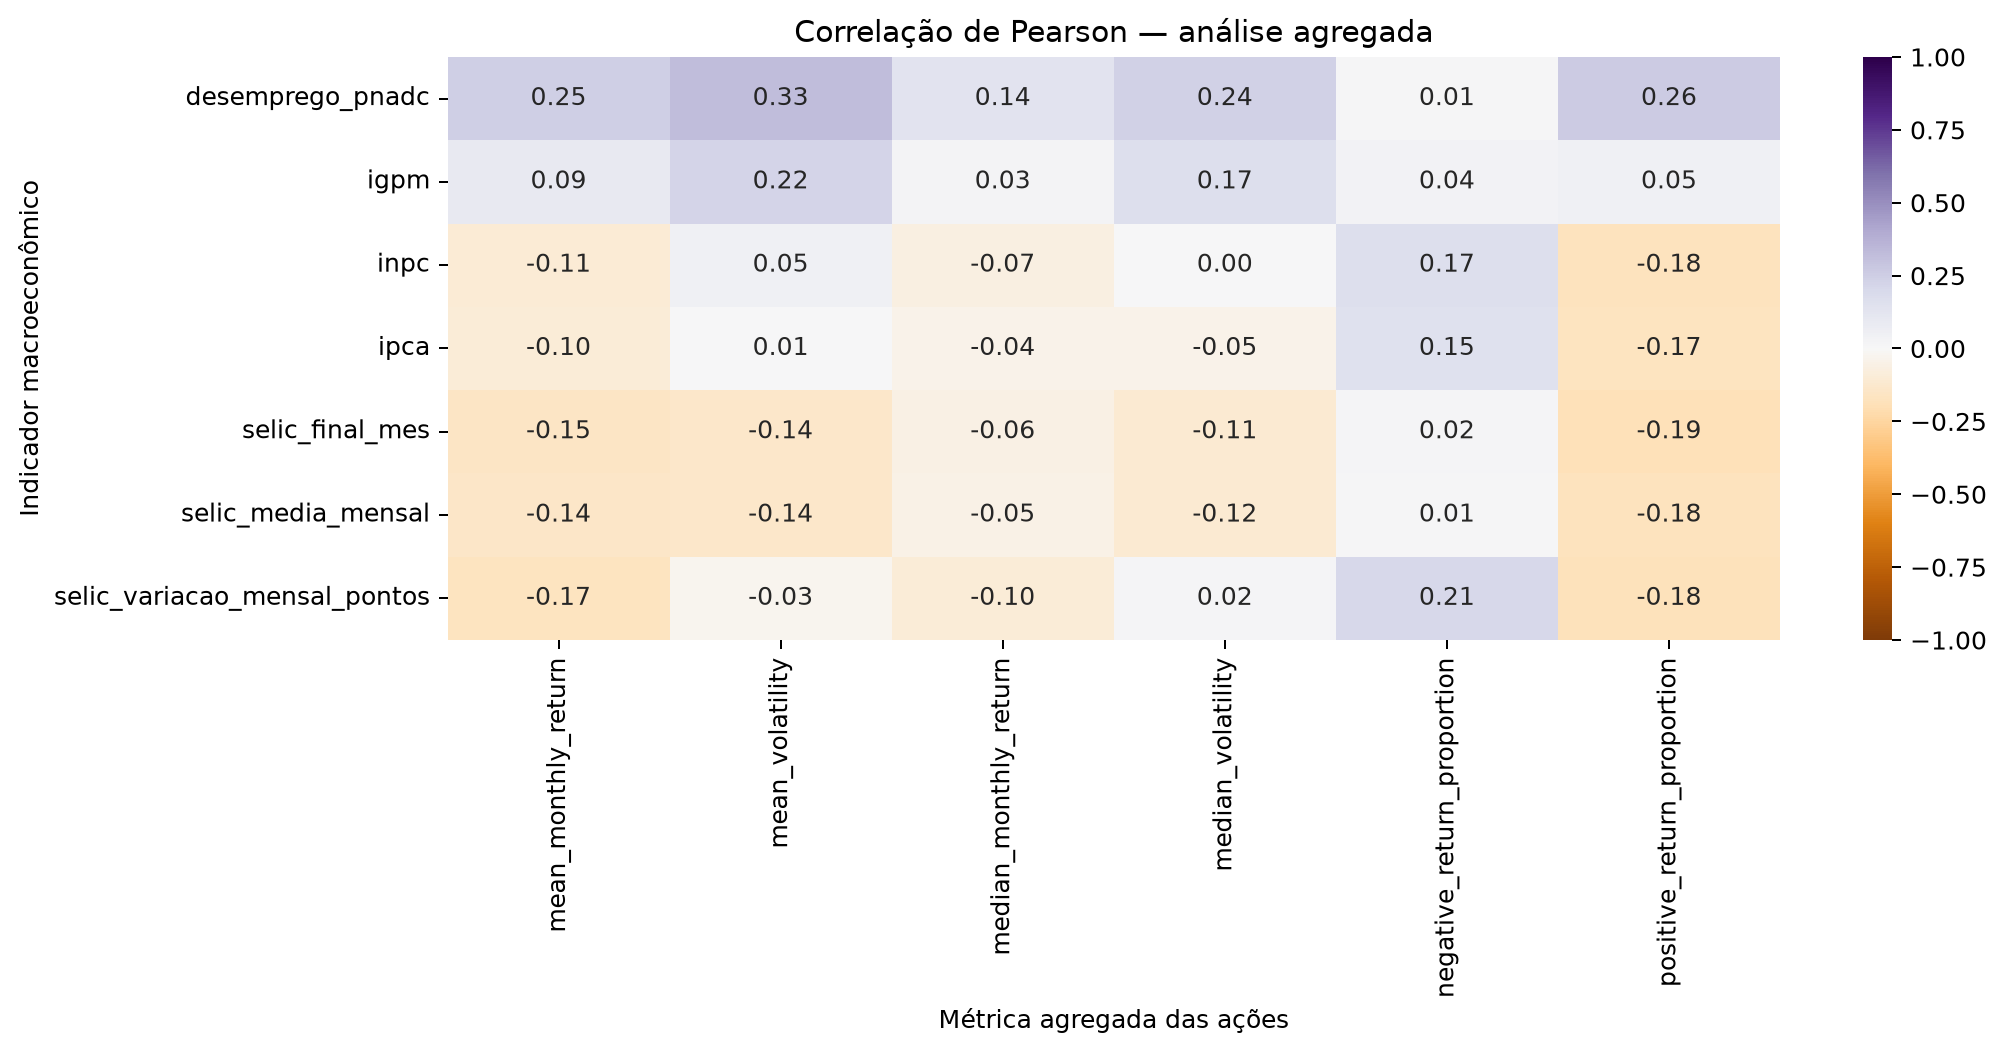

Spearman: associação monotônica por postos, mesmos pares.


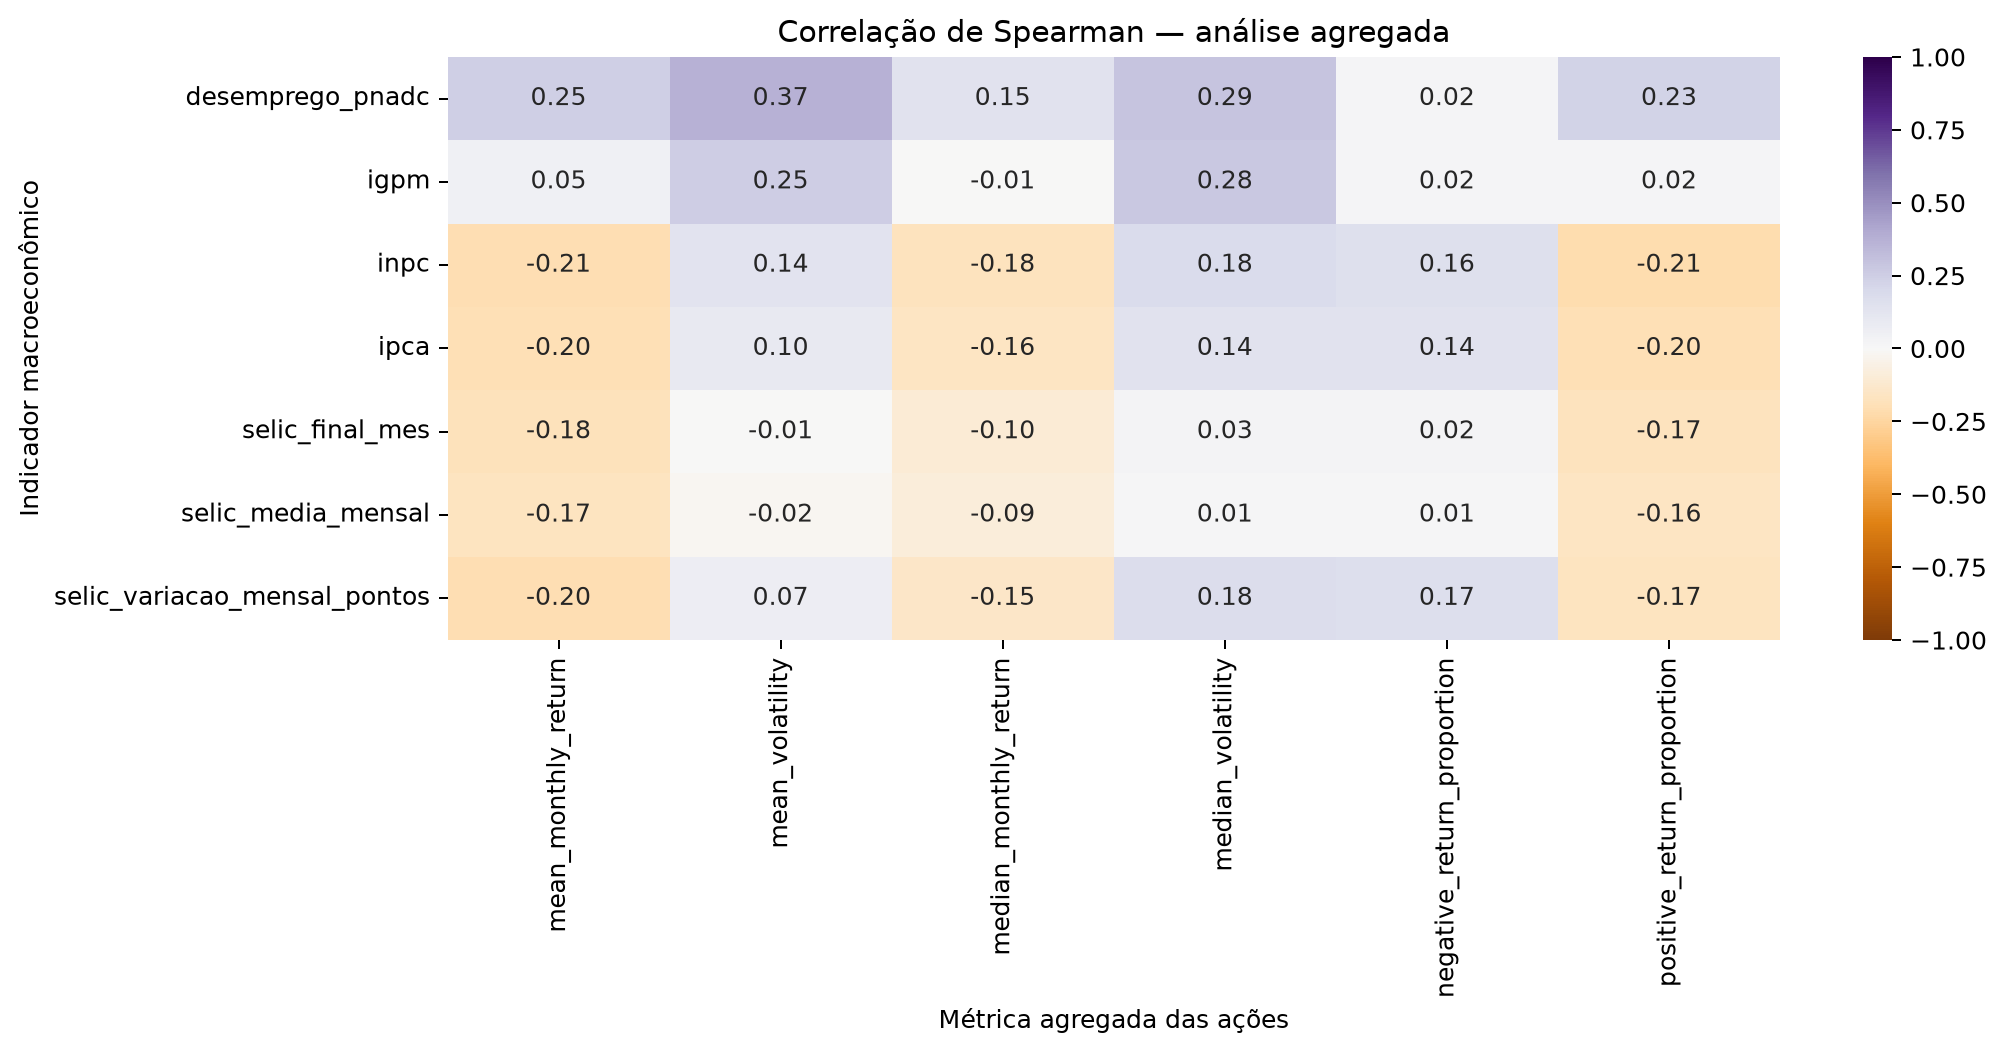

Quatro maiores |Pearson|: seleção exploratória, sem previsão.


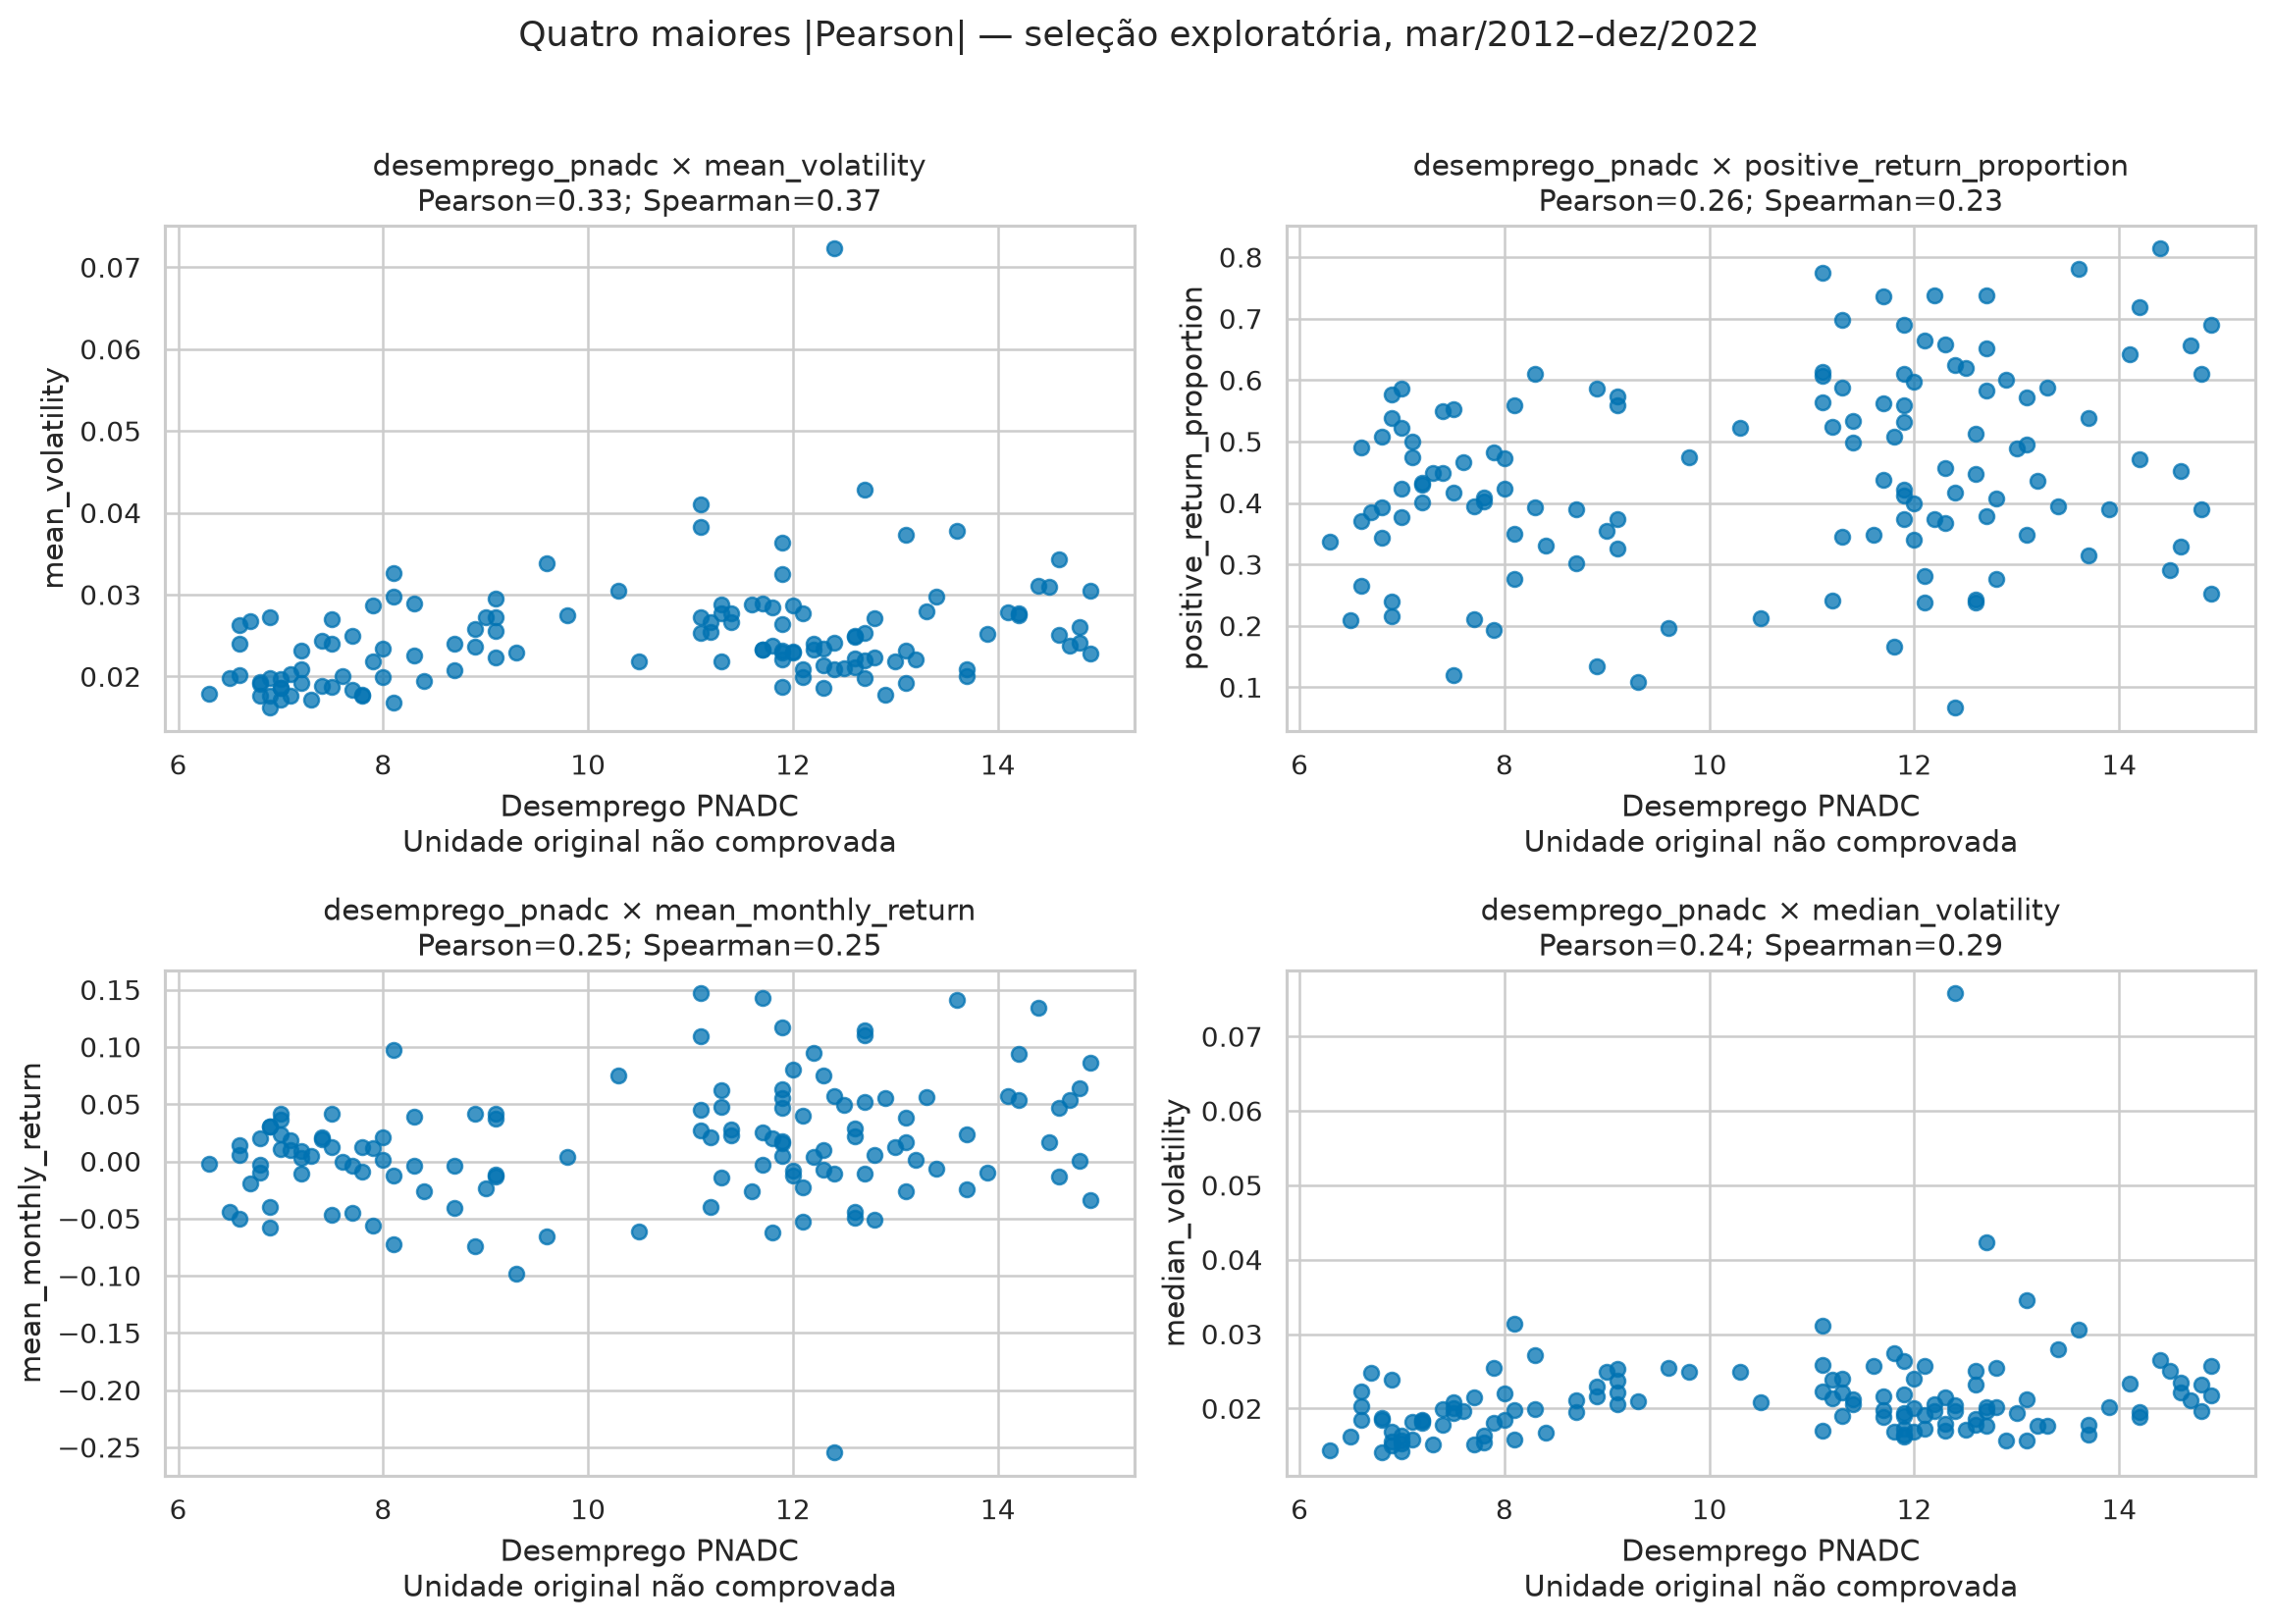

In [7]:
for name, explanation in [
    ('correlation_pearson_heatmap.png', 'Pearson: associação linear, todas as relações agregadas.'),
    ('correlation_spearman_heatmap.png', 'Spearman: associação monotônica por postos, mesmos pares.'),
    ('correlation_selected_scatterplots.png', 'Quatro maiores |Pearson|: seleção exploratória, sem previsão.'),
]:
    print(explanation)
    display(Image(filename=str(FIGURES / name)))

### Resultados individuais e cobertura por ticker

As correlações salvas alinham cada ticker e indicador por mês. A elegibilidade é **por par indicador–métrica**, com pelo menos 24 pares mensais válidos. Já o resumo por ticker exige o limiar em **todas as combinações**: na amostra atual, 212 de 215 atendem; F11, G11 e SRNA3 ficam abaixo do limiar e têm sua cobertura mostrada integralmente. O limiar é operacional, não garantia de independência ou precisão.

A cobertura completa dos 215 tickers aparece em tabela HTML com rolagem, sem truncamento. Para exemplificar resultados individuais sem selecionar pelo coeficiente ou p-value, exibimos os três primeiros tickers elegíveis em ordem alfabética, com todas as 14 relações de cada ticker e ambos os métodos. A tabela completa de coeficientes permanece em `outputs/tables/correlation_by_ticker.csv`. Esta regra de apresentação não é uma alegação de pré-registro.

In [8]:
by_ticker = pd.read_csv(TABLES / 'correlation_by_ticker.csv')
eligible_tickers = ticker_summary.loc[ticker_summary['eligible_primary_analysis'].eq(True)].sort_values('Symbol')
ineligible_tickers = ticker_summary.loc[ticker_summary['eligible_primary_analysis'].eq(False)].sort_values('Symbol')
print(f'Cobertura: {len(eligible_tickers)} de {len(ticker_summary)} tickers elegíveis em todas as combinações.')
display(ticker_summary[['months_with_data', 'valid_return_months', 'valid_volatility_months', 'min_observations', 'max_observations']].agg(['min', 'median', 'max']))
print('Todos os tickers ineligíveis no resumo:')
show_complete_table(ineligible_tickers)
print('Cobertura completa por ticker (rolagem, sem truncamento):')
show_complete_table(ticker_summary.sort_values('Symbol'))

selected_tickers = eligible_tickers['Symbol'].head(3).tolist()
print('Exemplos pela regra alfabética:', ', '.join(selected_tickers))
for symbol in selected_tickers:
    individual = by_ticker.loc[by_ticker['Symbol'].eq(symbol)]
    paired = individual.pivot(index=keys, columns='method', values=values)
    paired.columns = [f'{value}_{method}' for value, method in paired.columns]
    print(f'{symbol}: todas as 14 relações; p-values nominais não ajustados; n = pares mensais válidos.')
    show_complete_table(paired.reset_index())

Cobertura: 212 de 215 tickers elegíveis em todas as combinações.


,months_with_data,valid_return_months,valid_volatility_months,min_observations,max_observations
min,9.0,8.0,8.0,8.0,8.0
median,130.0,130.0,130.0,130.0,130.0
max,130.0,130.0,130.0,130.0,130.0


Todos os tickers ineligíveis no resumo:


Symbol,months_with_data,valid_return_months,valid_volatility_months,min_observations,max_observations,eligible_primary_analysis
F11,14,13,14,13,14,False
G11,9,8,8,8,8,False
SRNA3,13,12,13,12,13,False


Cobertura completa por ticker (rolagem, sem truncamento):


...

macro_indicator,stock_metric,coefficient_pearson,coefficient_spearman,p_value_pearson,p_value_spearman,n_observations_pearson,n_observations_spearman
desemprego_pnadc,monthly_return,0.106595,0.0415661,0.232954,0.642651,127,127
desemprego_pnadc,volatility_daily_return,0.0246154,0.205578,0.782701,0.0199146,128,128
igpm,monthly_return,0.0540691,0.0368353,0.546013,0.680964,127,127
igpm,volatility_daily_return,-0.00651595,0.162985,0.941808,0.0660354,128,128
inpc,monthly_return,-0.061528,-0.0368944,0.491969,0.68048,127,127
inpc,volatility_daily_return,0.0751126,0.202068,0.39942,0.0221749,128,128
ipca,monthly_return,-0.0707048,-0.0502225,0.429578,0.574977,127,127
ipca,volatility_daily_return,0.0524848,0.174367,0.556278,0.0490118,128,128
selic_final_mes,monthly_return,-0.151526,-0.115985,0.0890253,0.194098,127,127
selic_final_mes,volatility_daily_return,0.00174019,-0.0344867,0.984446,0.699156,128,128


AFLT3: todas as 14 relações; p-values nominais não ajustados; n = pares mensais válidos.


macro_indicator,stock_metric,coefficient_pearson,coefficient_spearman,p_value_pearson,p_value_spearman,n_observations_pearson,n_observations_spearman
desemprego_pnadc,monthly_return,0.0877809,0.093628,0.320657,0.289353,130,130
desemprego_pnadc,volatility_daily_return,0.157963,0.37905,0.0726614,8.69912e-06,130,130
igpm,monthly_return,-0.095035,-0.104932,0.282135,0.234781,130,130
igpm,volatility_daily_return,-0.0595931,0.0137087,0.500628,0.876978,130,130
inpc,monthly_return,-0.183098,-0.212683,0.0370569,0.0151237,130,130
inpc,volatility_daily_return,-0.254442,-0.346794,0.00348576,5.29859e-05,130,130
ipca,monthly_return,-0.190499,-0.227224,0.0299336,0.00932706,130,130
ipca,volatility_daily_return,-0.260009,-0.345827,0.00281285,5.57722e-05,130,130
selic_final_mes,monthly_return,-0.0262813,0.0726777,0.766611,0.411226,130,130
selic_final_mes,volatility_daily_return,-0.185613,-0.305166,0.0344912,0.000414896,130,130


AGRO3: todas as 14 relações; p-values nominais não ajustados; n = pares mensais válidos.


macro_indicator,stock_metric,coefficient_pearson,coefficient_spearman,p_value_pearson,p_value_spearman,n_observations_pearson,n_observations_spearman
desemprego_pnadc,monthly_return,0.100599,0.0195409,0.25478,0.82535,130,130
desemprego_pnadc,volatility_daily_return,-0.141486,-0.109571,0.108342,0.214613,130,130
igpm,monthly_return,0.138526,0.155356,0.116004,0.0775718,130,130
igpm,volatility_daily_return,0.104934,0.152583,0.234771,0.0830815,130,130
inpc,monthly_return,-0.0262061,0.00711006,0.76726,0.93601,130,130
inpc,volatility_daily_return,0.0890872,0.188858,0.31348,0.0314039,130,130
ipca,monthly_return,-0.0341442,0.000461608,0.699751,0.995841,130,130
ipca,volatility_daily_return,0.03346,0.112641,0.705487,0.201969,130,130
selic_final_mes,monthly_return,-0.0774678,-0.00644096,0.381,0.942021,130,130
selic_final_mes,volatility_daily_return,-0.0309603,0.0171987,0.726581,0.846007,130,130


### Distribuição dos coeficientes individuais

O resumo abaixo é calculado somente dos coeficientes já salvos, sem recalcular correlações. Cada grupo indicador–métrica–método inclui os pares elegíveis (`n_observations >= 24`) com coeficiente disponível. `count` conta coeficientes/tickers, não meses nem observações independentes.

A figura contém sete linhas (indicadores) e duas colunas (retorno e volatilidade), com caixas de Pearson e Spearman em cada painel e eixo vertical de −1 a 1. A elegibilidade é por combinação, não pelo filtro de todas as combinações do resumo por ticker. Mediana, quartis e caudas descrevem heterogeneidade de sinal e magnitude entre ativos. Os tickers compartilham condições de mercado e indicadores: não são réplicas independentes. As caixas não constituem intervalos de confiança nem demonstram causalidade.

Distribuição descritiva dos coeficientes salvos: todos os 28 grupos, sem truncamento.


macro_indicator,stock_metric,method,count,mean,std,min,25%,50%,75%,max
desemprego_pnadc,monthly_return,pearson,212,0.0761983,0.0930873,-0.189863,0.0194356,0.0785149,0.138034,0.284641
desemprego_pnadc,monthly_return,spearman,212,0.0549802,0.09998,-0.208243,-0.0124571,0.0372792,0.132778,0.282029
desemprego_pnadc,volatility_daily_return,pearson,212,0.0849282,0.175127,-0.486383,-0.0103514,0.0892484,0.194007,0.568952
desemprego_pnadc,volatility_daily_return,spearman,212,0.113948,0.220848,-0.45712,-0.033142,0.105095,0.285319,0.620131
igpm,monthly_return,pearson,212,0.0216225,0.0819879,-0.159016,-0.0307106,0.0155424,0.0707068,0.266227
igpm,monthly_return,spearman,212,0.00241836,0.0801572,-0.201179,-0.055898,0.00455716,0.0564475,0.214182
igpm,volatility_daily_return,pearson,212,0.0630788,0.0981424,-0.178091,-0.00093562,0.0585146,0.117953,0.314825
igpm,volatility_daily_return,spearman,212,0.0873329,0.11066,-0.237953,0.0120327,0.0891657,0.174532,0.346516
inpc,monthly_return,pearson,212,-0.0439022,0.0834211,-0.289823,-0.101629,-0.0426864,0.013364,0.199933
inpc,monthly_return,spearman,212,-0.057028,0.0876935,-0.378901,-0.112204,-0.0583698,0.00459926,0.149203


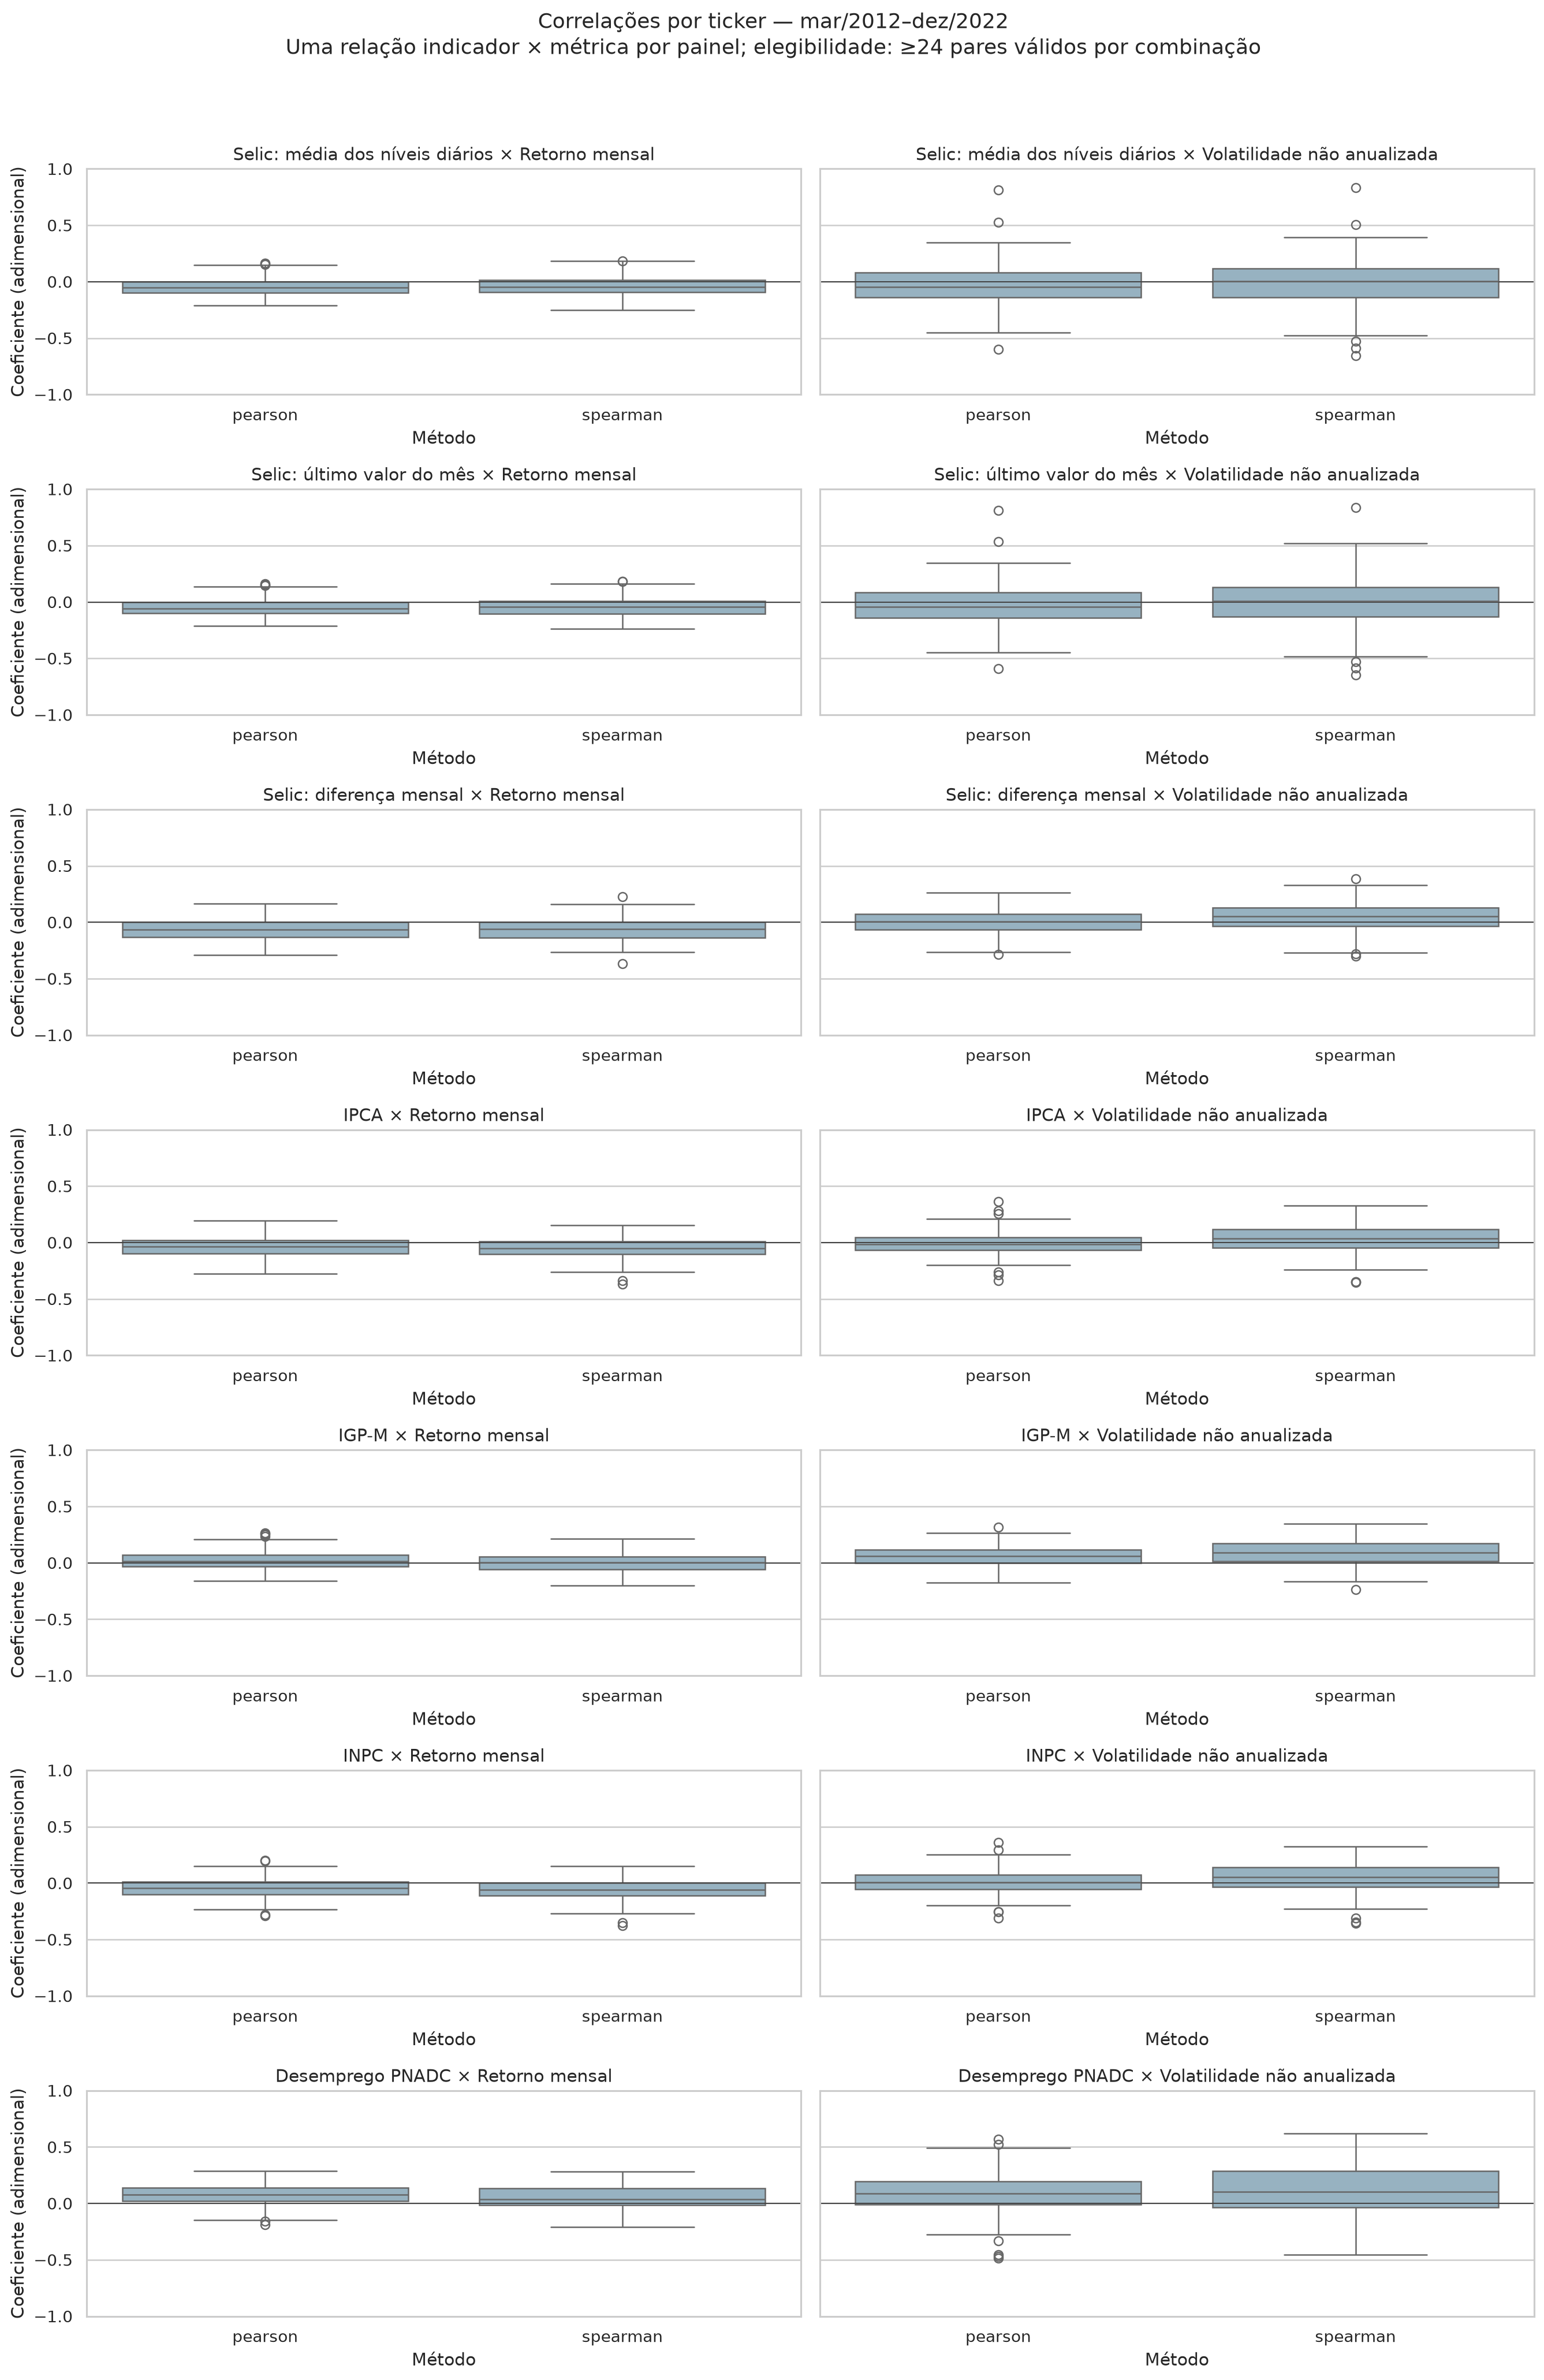

In [9]:
eligible_pairs = by_ticker.loc[by_ticker['n_observations'].ge(24) & by_ticker['coefficient'].notna()]
coefficient_distribution = (eligible_pairs.groupby(['macro_indicator', 'stock_metric', 'method'])['coefficient']
                            .describe(percentiles=[0.25, 0.5, 0.75]).reset_index())
print('Distribuição descritiva dos coeficientes salvos: todos os 28 grupos, sem truncamento.')
show_complete_table(coefficient_distribution)
display(Image(filename=str(FIGURES / 'correlation_ticker_distributions.png')))

### Limitações e alcance da leitura

- A seleção dos 215 tickers é retrospectiva e utiliza histórico que se estende além de 2022, podendo produzir viés de seleção. A composição mensal varia e os agregados não são ponderados por capitalização; não representam um índice de mercado.
- Ativos presentes, retornos válidos e volatilidades válidas têm coberturas distintas. Retorno zero não é positivo nem negativo, portanto as duas proporções não precisam somar 1. Cobertura em meses não comprova completude ou qualidade em sessões.
- Retorno mensal usa os últimos registros válidos de meses consecutivos. A volatilidade amostral não anualizada usa retornos entre registros válidos, com possíveis lacunas. Extremos e limitações de qualidade permanecem relevantes após o saneamento.
- As associações são contemporâneas e bivariadas, sem controles ou defasagens. Compartilhar um rótulo de mês não comprova data de divulgação nem disponibilidade da informação naquele momento. Origem externa e unidades macroeconômicas continuam incompletamente documentadas.
- O limiar de 24 pares é operacional e difere dos 24 meses com registros exigidos na seleção dos ativos. Dependência temporal e entre ativos, multiplicidade e ausência de ajustes impedem leitura confirmatória dos p-values nominais. Spearman não elimina essas limitações. Se a coluna PNADC corresponder a trimestres móveis, suas janelas se sobrepõem.

A conclusão se limita à direção, magnitude e consistência das associações na janela analisada. Diferenças entre métodos devem ser lidas em conjunto com distribuição, empates, extremos e cobertura; não sustentam causalidade, previsão de preços ou recomendação de investimento.